In [1]:
# !pip install numpy
# !pip install 
# !pip install scipy

In [2]:
import numpy as np 
import matplotlib.pyplot as plt 

## Read in data

In [3]:
filename = 'Photogrammetry-03-23-36.txt'
arr = np.loadtxt(filename, usecols=range(1, 8))

In [4]:
x = arr[:,0]
y = arr[:,1]
z = arr[:,2]

## Visualize as is

In [33]:
def vis(x,y,z, ind=False, asp=False, Verdose=False): 
    fig = plt.figure(figsize=(12, 10))

 
    # 3D plot
    ax1 = fig.add_subplot(221, projection='3d')
    ax1.scatter(x, y, z, c='blue')
    # ax1.set_title('3D Plot')
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_zlabel('Z')
    if Verdose: 
            ax1.set_title(f"Maximum difference: {max(z)-min(z):.4f} (mm)")

    # XY plane
    ax2 = fig.add_subplot(222)
    ax2.scatter(x, y, c='red')
    if ind:
        for i, (xi, yi) in enumerate(zip(x, y)):
            ax2.text(xi, yi, str(i), fontsize=9, color='black')
    # ax2.set_title('XY Plane')
    ax2.set_xlabel('X')
    ax2.set_ylabel('Y')
    ax2.set_aspect("equal")
    ax2.grid()

    # XZ plane
    ax3 = fig.add_subplot(223)
    ax3.scatter(x, z, c='green')
    # ax3.set_title('YZ Plane')
    ax3.set_xlabel('X')
    ax3.set_ylabel('Z')
    ax3.grid()


    # YZ plane
    ax4 = fig.add_subplot(224)
    ax4.scatter(y, z, c='purple')
    # ax4.set_title(' Plane')
    ax4.set_xlabel('Y')
    ax4.set_ylabel('Z')
    ax4.grid()

    if asp: 
        ax3.set_ylim(min(z)*0.5, max(z)*1.3)
        ax4.set_ylim(min(z)*0.5, max(z)*1.3)
  

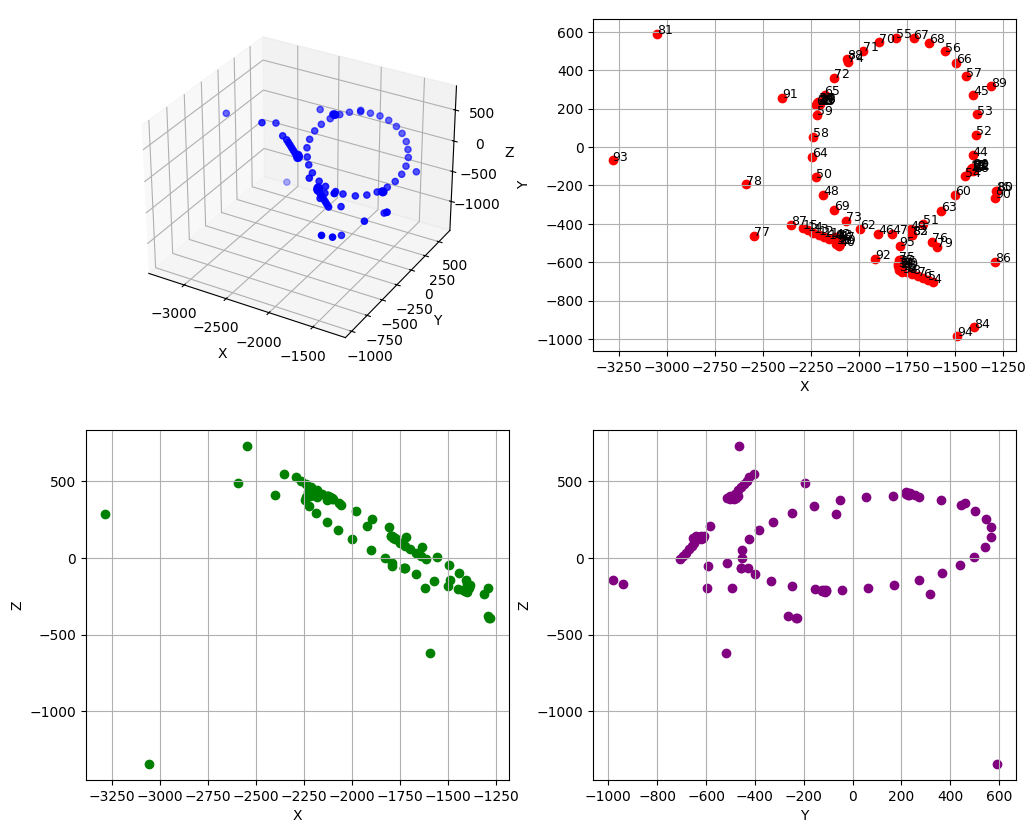

In [6]:
vis(x,y,z, ind=True)

## Get reference points

In [7]:
xb = x[4:16]
yb = y[4:16]
zb = z[4:16]

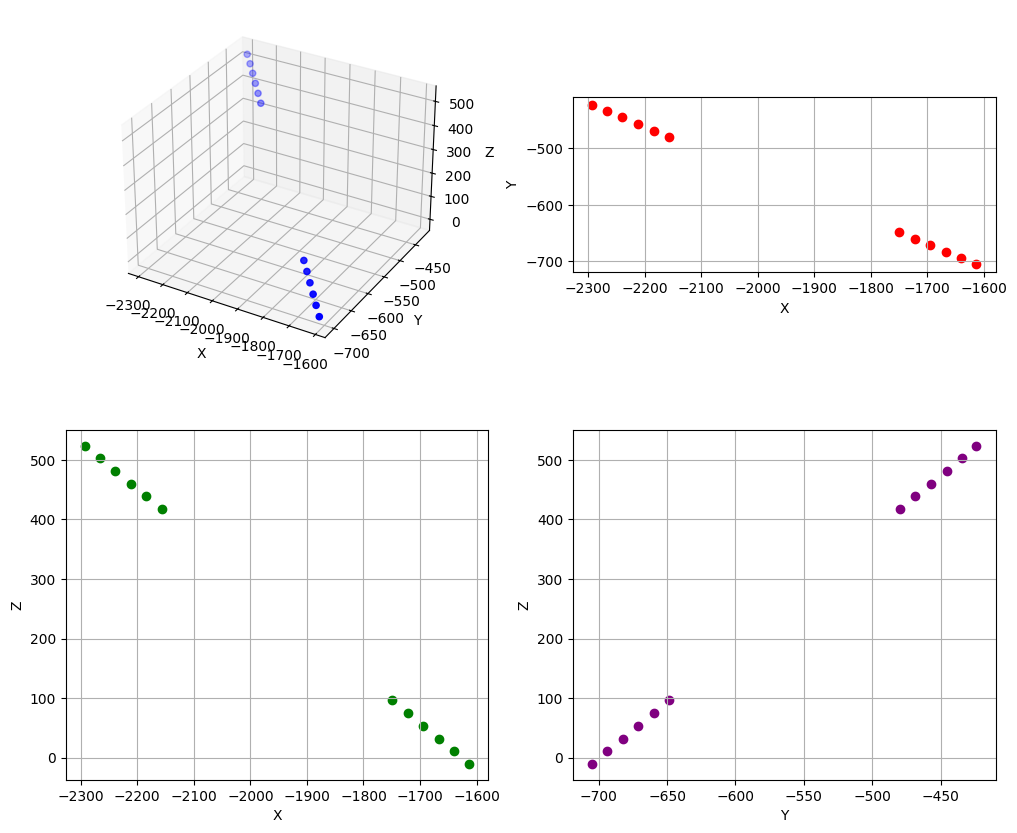

In [8]:
vis(xb, yb, zb)

## Get points of interest

In [9]:
xp = x[44:75]
yp = y[44:75]
zp = z[44:75]

In [10]:
xp = np.delete(xp, 17)
yp = np.delete(yp, 17)
zp = np.delete(zp, 17)

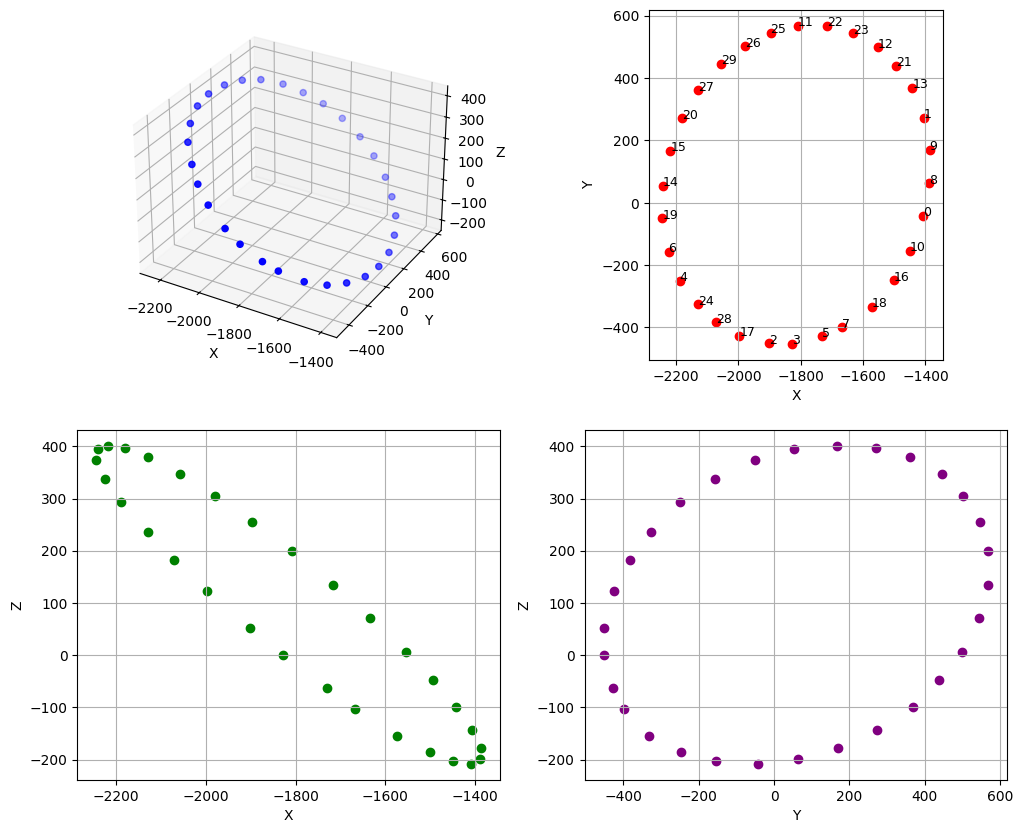

In [11]:
vis(xp, yp, zp, ind=True)

## Set up PCA 

In [12]:
def pca_rotate(ref, pts):
    """
    Run PCA on reference points xr, yr, zr and rotate coordinate of all points
    """

    # references 
    mean_ref = ref.mean(axis=0)
    ref_centered = ref - mean_ref

    U, S, Vt = np.linalg.svd(ref_centered, full_matrices=False)
    R = Vt.T   

    rotated_ref = ref_centered @ R

    # other points
    pts_centered = pts - mean_ref

    rotated_pts = pts_centered @ R

    Xr, Yr, Zr = rotated_ref.T
    X, Y, Z = rotated_pts.T

    return Xr, Yr, Zr, X, Y, Z, R, mean_ref


In [13]:
ref = np.vstack([xb, yb, zb]).T  
pts = np.vstack([xp, yp, zp]).T 

In [14]:
Xr, Yr, Zr, X, Y, Z, _, _ = pca_rotate(pts, ref)

In [15]:
x, y, z = np.append(Xr, X), np.append(Yr, Y), np.append(Zr, Z)

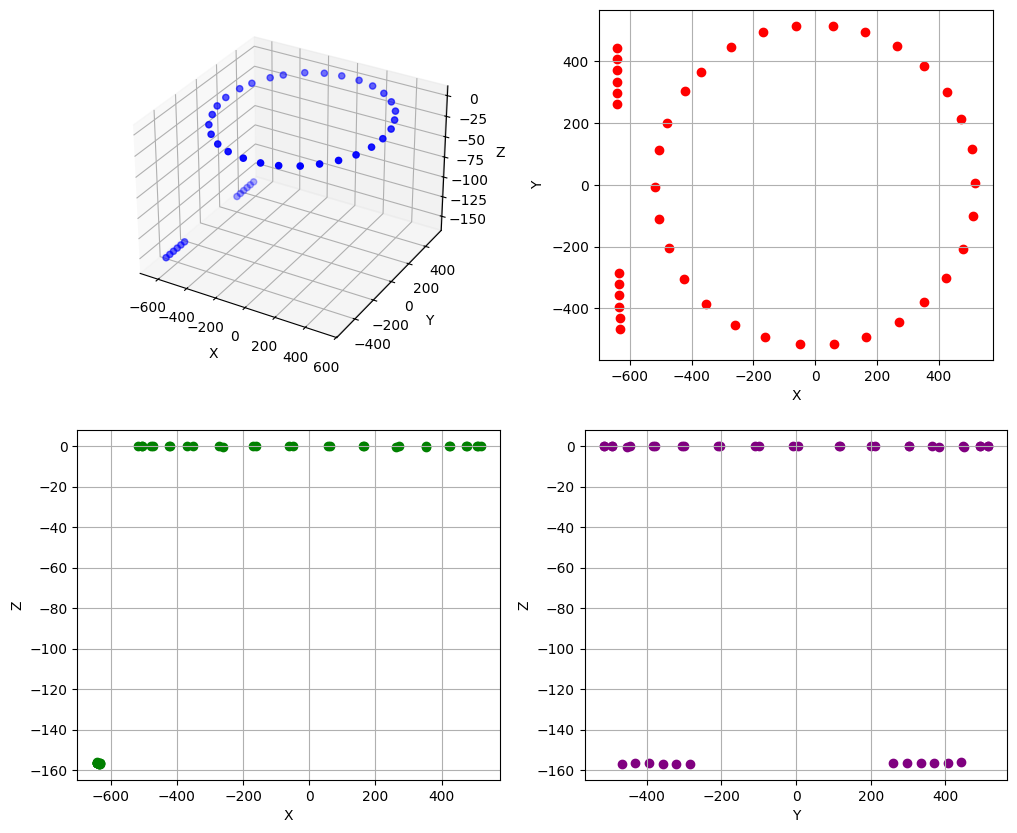

In [16]:
vis(x,y,z)

In [17]:
## To match XY on physical system, interchange labelings
x_p = Yr
y_p = Xr
z_p = Zr

## Interpolation and surface fit

In [18]:
from scipy.interpolate import griddata

def surfacefit(x, y, z, method='cubic', gridsize=200):
    
    xi = np.linspace(min(x), max(x), gridsize)
    yi = np.linspace(min(y), max(y), gridsize)
    Xg, Yg = np.meshgrid(xi, yi)

    Zg = griddata(
        points=np.column_stack((x, y)),
        values=z,
        xi=(Xg, Yg),
        method=method
    )

    return Xg, Yg, Zg


In [19]:
Xg, Yg, Zg = surfacefit(x_p, y_p, z_p, method='cubic')

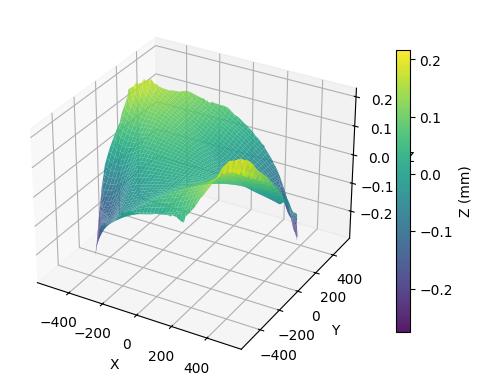

In [20]:
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(Xg, Yg, Zg, cmap='viridis', edgecolor='none', alpha=0.9)
# ax.scatter(Xr, Yr, Zr, color='red', s=40)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

fig.colorbar(surf, ax=ax, shrink=0.6, label='Z (mm)')
plt.tight_layout()


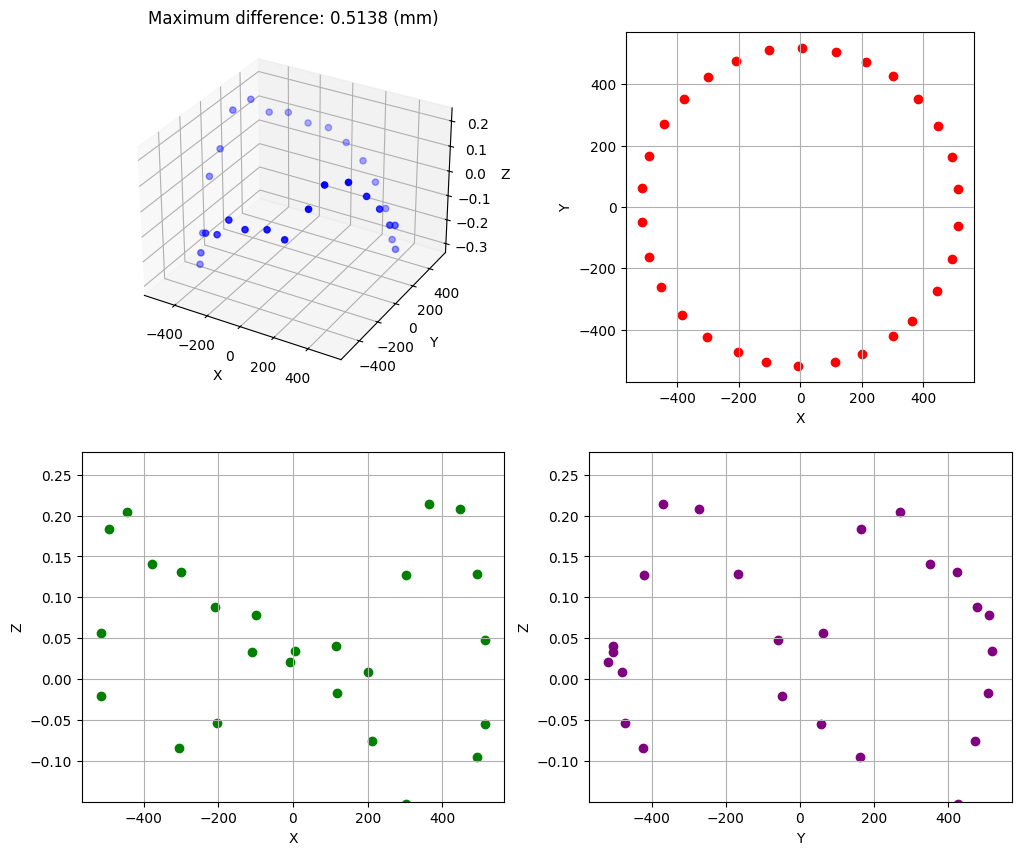

In [34]:
vis(x_p, y_p, z_p, asp=True, Verdose=True)